In [1]:
import cv2

In [2]:
vidname = 'highway1'
vidcap = cv2.VideoCapture(f'videos/{vidname}.mov')
success,image = vidcap.read()
count = 0
while success:
  cv2.imwrite(f'frames/{vidname}/frame%d.jpg' % count, image)      
  success,image = vidcap.read()
  count += 100

In [3]:
start = 84000
end = 129000

In [4]:
import sys
sys.path.insert(0, './Vehicle-Detection')

In [7]:
import matplotlib
matplotlib.use('Agg')  # Use non-interactive backend to avoid conflicts

from ultralytics import YOLO

In [ ]:
model = YOLO('yolov5m.pt')  # Auto-downloads

results = model.predict('videos/highway1.mov', conf=0.5)

PRO TIP 💡 Replace 'model=yolov5m.pt' with new 'model=yolov5mu.pt'.
YOLOv5 'u' models are trained with https://github.com/ultralytics/ultralytics and feature improved performance vs standard YOLOv5 models trained with https://github.com/ultralytics/yolov5.


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/5253) /Users/tanishasingh/Documents copy/UCI/Y3Q3/117_final/videos/highway1.mov: 384x640 4 cars, 1 traffic light, 193.3ms
video 1/1 (frame 2/5253) /Users/tanishasingh/Documents copy/

In [13]:
import matplotlib.pyplot as plt
annotated_frame = results[0].plot() 

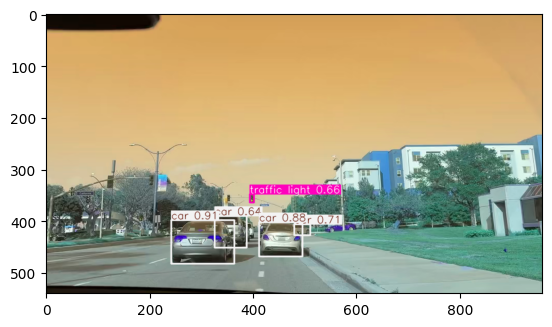

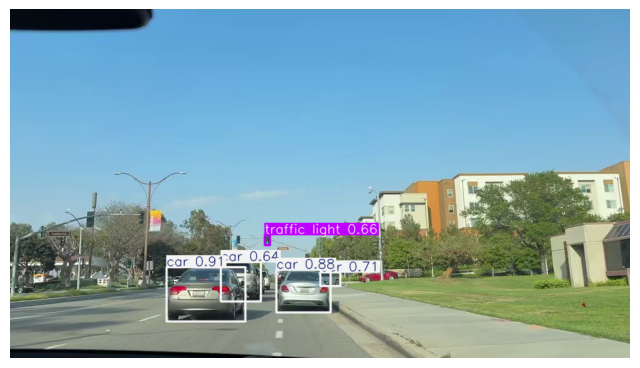

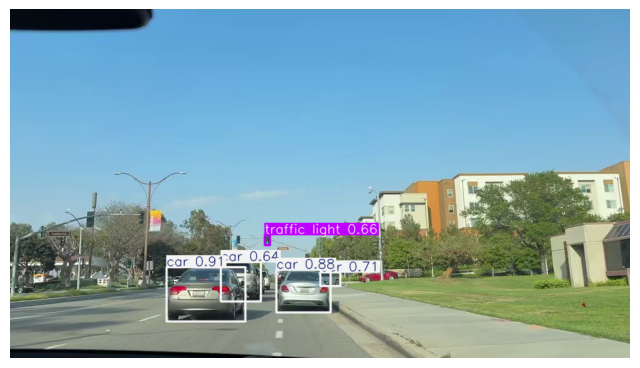

In [16]:

%matplotlib inline
plt.figure(figsize=(8, 6))
plt.imshow(annotated_frame[:, :, ::-1])  # BGR -> RGB (if this is from OpenCV/Ultralytics)
plt.axis("off")
plt.show()